# Modelo de Regressão para prever o seguro de saúde

Este projeto tem como objetivo construir um modelo de Machine Learning de **Regressão** capaz de prever os custos médicos individuais (`charges`) cobrados pelo seguro de saúde, utilizando características demográficas e de estilo de vida dos beneficiários.

## Objetivo
Criar um modelo preditivo de regressão para prever o valor dos custos médicos individuais cobrados pelo seguro de saúde.

## Sobre a base de dados
Essa base de dados contém 1.338 linhas com informações sobre a idade da pessoa, gênero, índice de massa corporal (IMC), número de filhos, flag de verificação se a pessoa é fumante, região residencial do benefício e o valor do custo médico.

Dicionário dos dados
* Idade: idade do beneficiário principal.
* Gênero: gênero do contratante de seguros.
*  IMC: Índice de massa corporal, fornecendo uma compreensão do corpo, pesos relativamente altos ou baixos em relação à altura.
* Filhos: número de filhos cobertos por seguro saúde / Número de dependentes.
* Fumante: se a pessoa fuma (sim ou não).
* Região: a área residencial do beneficiário nos EUA, nordeste, sudeste, sudoeste ou noroeste.
* Encargos: custos médicos individuais cobrados pelo seguro de saúde.


In [1]:
# Importando as bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [2]:
# Carregando os dados
df = pd.read_csv('dataset/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.shape

(1338, 7)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [5]:
# Verificando valores nulos
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Não há valores ausentes

In [6]:
# Verificando valores duplicados
print(f'Quantidade de linhas duplicadas: {df.duplicated().sum()}')

# Verificando qual valor está duplicado
print('\nVerificando qual linha tá duplicada:')
display(df[df.duplicated()])

# Filtrando pela idade de 19 anos, masculino e imc
print('\nVisualizando o valor duplicado:')
display(df[(df['age'] == 19) & (df['sex'] == 'male') & (df['bmi'] == 30.59)])

Quantidade de linhas duplicadas: 1

Verificando qual linha tá duplicada:


,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631



Visualizando o valor duplicado:


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


O nosso dataset possui um valor duplicado, entretanto esse valor pode ser de pessoas diferentes, pois duas pessoas podem ter as mesmas características, por isso, não será deletado.

## Análise das Variáveis Quantitativas

In [7]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


**Charges - Custos Médicos**
* A variável `charges` (target) apresentou média muito superior a mediana, indicando assimetria.
* O desvio padrão também apresentou valor alto comparado com a média, indicando que os custos variam muito entre os indivíduos.

**Age - Idade**
* A média e a mediana das idades estão bem próximas, demonstrando que a distribuição está bem distruída.

**BMI - IMC**
* A média apresentada pela nossa estatística descritiva aponta que os indivíduos analisados estão com IMC 30.4, valor classificado como obesidade. 

**Children - Filhos**
* 25% dos nossos indivíduos não possuem filhos e em média, o número de filhos é 1.09. 

### Idade

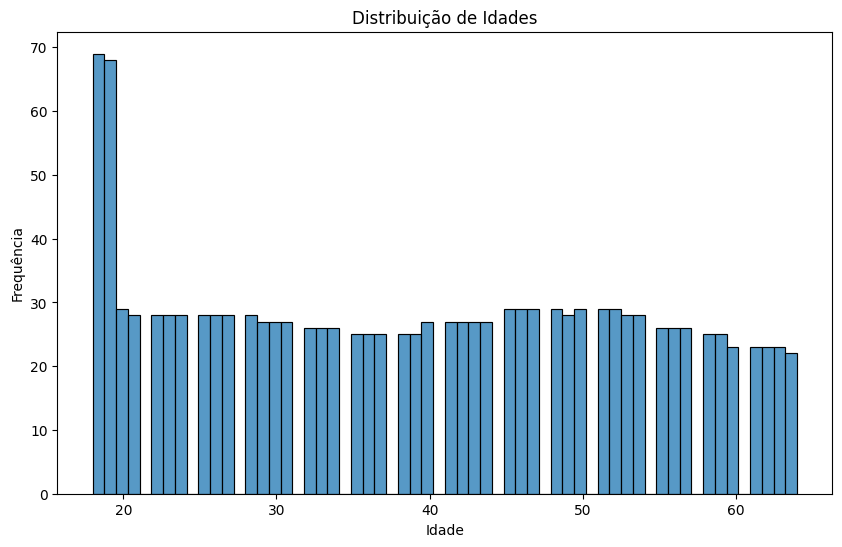

In [8]:
# Histograma de idades
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], bins=60)
plt.title('Distribuição de Idades')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.show()

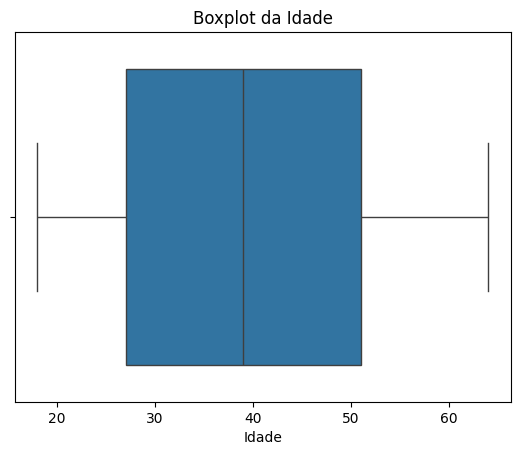

In [9]:
sns.boxplot(x=df['age'])
plt.title('Boxplot da Idade')
plt.xlabel('Idade')
plt.show()

### IMC

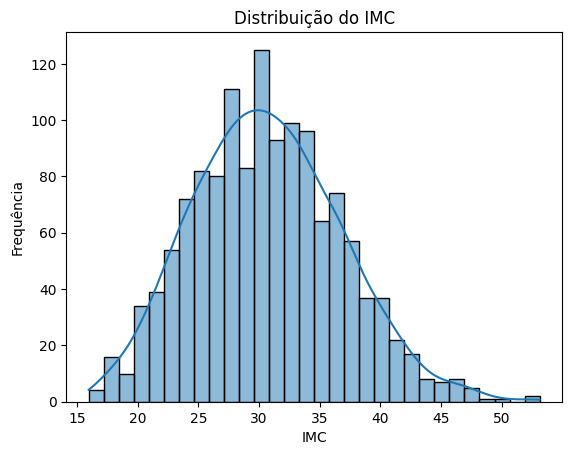

In [10]:
sns.histplot(df['bmi'], bins=30, kde=True)
plt.title('Distribuição do IMC')
plt.xlabel('IMC')
plt.ylabel('Frequência')
plt.show()

In [11]:
# Verificando se IMC possui distribuição normal
stat_sw, p_sw = stats.shapiro(df['bmi'])
print(f'Estatistica de Shapiro-Wilk: {stat_sw}, p-valor:{p_sw}')

if p_sw <= 0.05:
    print("p-valor é menor que 0.05. Rejeita H0 - Os dados não são normalmente distruídos.")
else:
    print("p-valor é maior que 0.05. Não Rejeita H0 - Não há evidencia suficiente para dizer que os dados não são normais.")

Estatistica de Shapiro-Wilk: 0.9938864621676107, p-valor:2.6046836879834408e-05
p-valor é menor que 0.05. Rejeita H0 - Os dados não são normalmente distruídos.


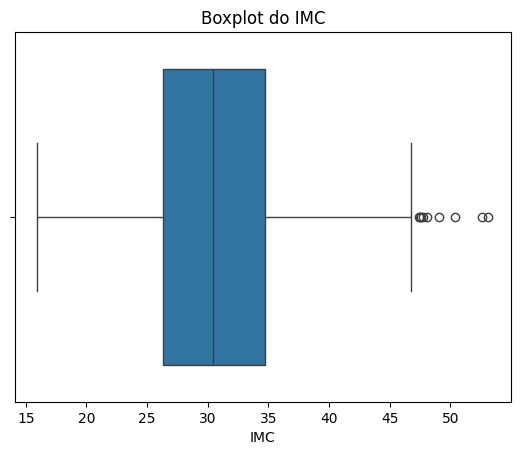

In [12]:
sns.boxplot(x=df['bmi'])
plt.title('Boxplot do IMC')
plt.xlabel('IMC')
plt.show()  

### Número de Filhos

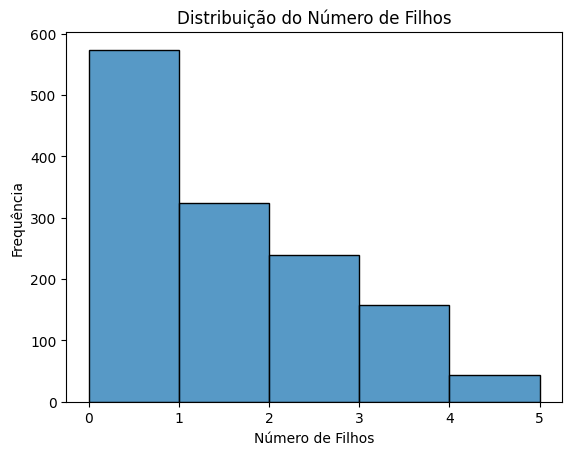

In [13]:
sns.histplot(df['children'], bins=5)
plt.title('Distribuição do Número de Filhos')
plt.xlabel('Número de Filhos')
plt.ylabel('Frequência')
plt.show()

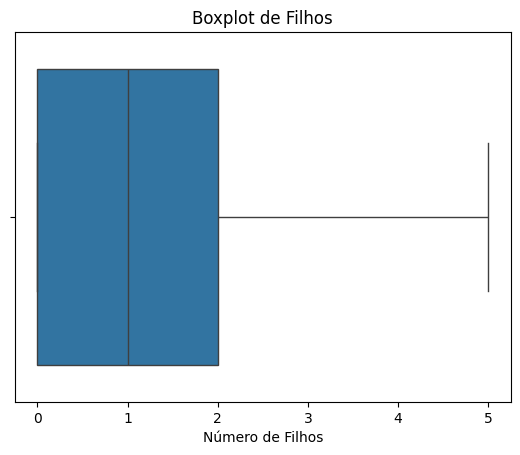

In [14]:
sns.boxplot(x=df['children'])
plt.title('Boxplot de Filhos')
plt.xlabel('Número de Filhos')
plt.show()

### Custos médicos

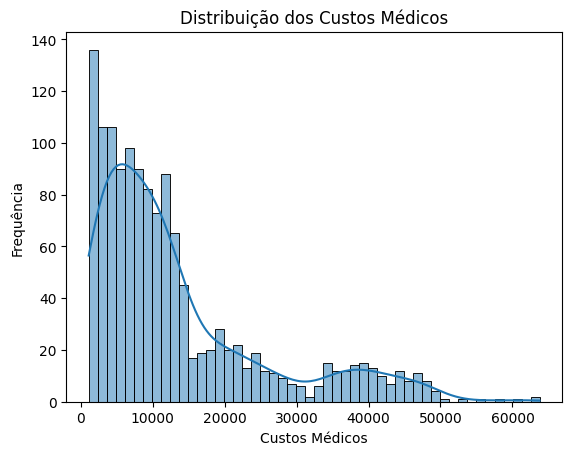

In [15]:
sns.histplot(df['charges'], bins=50, kde=True)
plt.title('Distribuição dos Custos Médicos')
plt.xlabel('Custos Médicos')
plt.ylabel('Frequência')
plt.show()

Nos resultados da estatística descritiva já tinhamos uma ideia de que os custos médicos não apresentariam uma distribuição normal. Com o histograma podemos visualizar que a distribuição dessa variável é unicaudal e para direita.

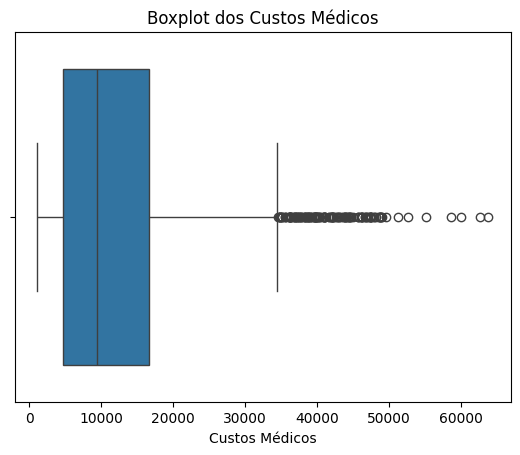

In [16]:
sns.boxplot(x=df['charges'])
plt.title('Boxplot dos Custos Médicos')
plt.xlabel('Custos Médicos')
plt.show()

## Análise das Variáveis Categóricas

### Sexo

In [17]:
sexo = df['sex'].value_counts()
sexo_percentual = round((sexo/len(df)*100), 2)
sexo_df = pd.DataFrame({'Quantidade': sexo, 'Percentual (%)': sexo_percentual})
sexo_df

,Quantidade,Percentual (%)
sex,,
male,676,50.52
female,662,49.48


### Fumante

In [18]:
fumante = df['smoker'].value_counts()
fumante_percentual = round((fumante/len(df)*100), 2)
fumante_df = pd.DataFrame({'Quantidade': fumante, 'Percentual (%)': fumante_percentual})
fumante_df

,Quantidade,Percentual (%)
smoker,,
no,1064,79.52
yes,274,20.48


### Região

In [19]:
regiao = df['region'].value_counts()
regiao_percentual = round((regiao/len(df)*100), 2)
regiao_df = pd.DataFrame({'Quantidade': regiao, 'Percentual (%)': regiao_percentual})
regiao_df

,Quantidade,Percentual (%)
region,,
southeast,364,27.20
southwest,325,24.29
northwest,325,24.29
northeast,324,24.22


## Teste de Hipótese

### Há diferença entre os custos médios entre os sexos?

* H0: Não há diferença significativa de custos entre os gêneros
* H1: Há diferença significativa de custos entre os gêneros

In [20]:
# Teste t de Student para verificar se há diferença
male = df[df['sex']=='male']['charges']
female = df[df['sex']=='female']['charges']

t_stat, p_value = stats.ttest_ind(male, female, equal_var=False)
print(f'Estatistica t: {t_stat}, p-valor: {p_value}')

Estatistica t: 2.1008878232359565, p-valor: 0.03584101495601666


p-valor < 0,05, então rejeitamos H0. 

Então há diferença entre as médias dos custos entre os gêneros. Também podemos verificar com o gráfico a seguir:

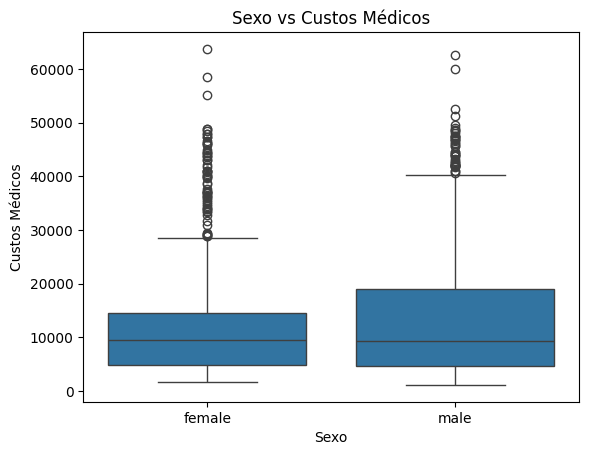

In [21]:
# Sexo e custos médicos
sns.boxplot(x='sex', y='charges', data=df)
plt.title('Sexo vs Custos Médicos')
plt.xlabel('Sexo')
plt.ylabel('Custos Médicos')
plt.show()

No gráfico, temos que o sexo masculino tem maiores custos médicos comparado com as mulheres.

### Há diferença entre os custos médios de fumantes e não-fumantes?

* H0: Não há diferença significativa nos custos médios entre fumantes e não-fumantes.
* H1: Há diferença significativa nos custos médios entre fumantes e não-fumantes.

In [22]:
smoker = df[df['smoker']=='yes']['charges']
no_smoker = df[df['smoker']=='no']['charges']

t_stat_smoker, p_value_smoker = stats.ttest_ind(smoker, no_smoker, equal_var=False)
print(f'Estatistica t: {t_stat_smoker}, p-valor: {p_value_smoker}')

Estatistica t: 32.751887766341824, p-valor: 5.889464446716939e-103


p-valor < 0,05, rejeitamos H0. 

Então há diferença entre as médias dos custos entre os fumantes e não fumantes. 

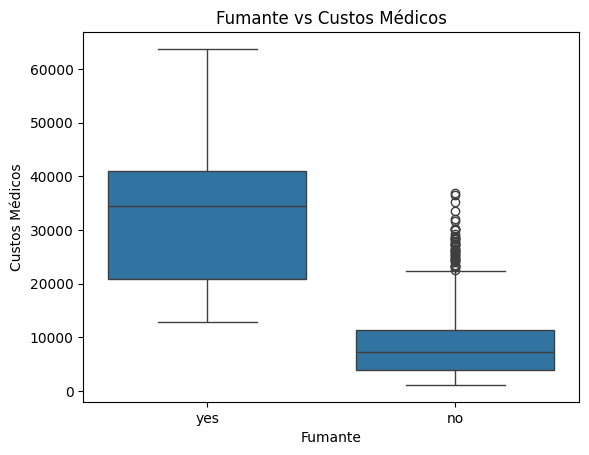

In [23]:
# Fumante e custos médicos
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Fumante vs Custos Médicos')
plt.xlabel('Fumante')
plt.ylabel('Custos Médicos')
plt.show()

No gráfico podemos observar que os custos médios para os fumantes é bem maior do que para os não fumantes.

### Os custos médios são iguais em todas as Regiões?

* H0: todos os custos médios por região são iguais
* H1: Pelo menos uma média de região é diferente das demais

In [24]:
# Usando statsmodels:
formula = 'charges ~ C(region)'
model = ols(formula, data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
anova_table

,sum_sq,df,F,PR(>F)
C(region),1.300760e+09,3.0,2.969627,0.030893
Residual,1.947735e+11,1334.0,NaN,NaN


In [25]:
# Usando scipy.stats:
northwest = df[df['region']=='northwest']['charges']
northeast = df[df['region']=='northeast']['charges']
southeast = df[df['region']=='southeast']['charges']
southwest = df[df['region']=='southwest']['charges']
f_statistic, p_value = stats.f_oneway(northwest, northeast, southeast, southwest)
print(f'\nEstatística F: {f_statistic:.4}, p-valor: {p_value:.4}')


Estatística F: 2.97, p-valor: 0.03089


p-value < 0.05. Isso significa que rejeitamos a Hipótese Nula. 

Há uma diferença estatisticamente significativa nas médias dos custos entre pelo menos um par de regiões.

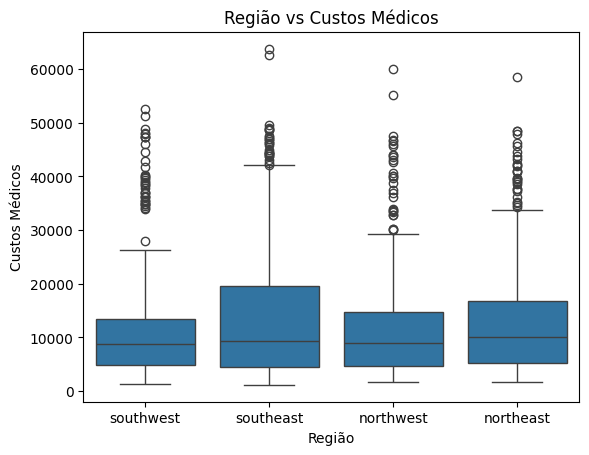

In [26]:
# Região e custos médicos
sns.boxplot(x='region', y='charges', data=df)
plt.title('Região vs Custos Médicos')
plt.xlabel('Região')
plt.ylabel('Custos Médicos')
plt.show()

A região Sudeste (southeast) apresenta a média de custos mais alta, o que provavelmente é o principal fator que impulsiona a diferença estatisticamente significativa.

### Todos os custos médios por número de dependentes são iguais?

* H0: Todos os custos médios de seguro por região são iguais.
* H1: Pelo menos uma média de dependentes é diferente das demais.

In [27]:
# Usando statsmodels:
formula = 'charges ~ C(children)'
model = ols(formula, data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
anova_table

,sum_sq,df,F,PR(>F)
C(children),2.396917e+09,5.0,3.29692,0.005786
Residual,1.936773e+11,1332.0,NaN,NaN


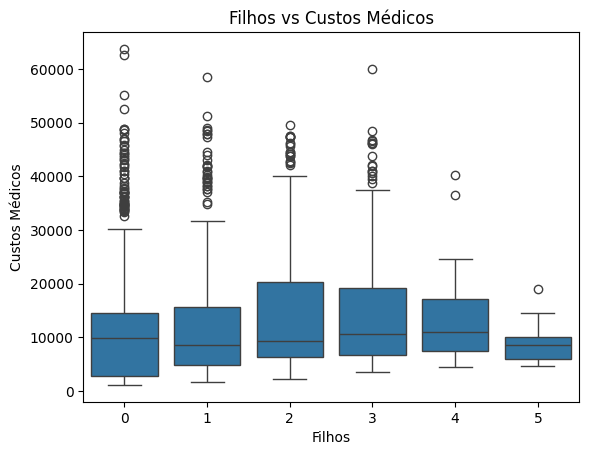

In [28]:
# Filhos e custos médicos
sns.boxplot(x='children', y='charges', data=df)
plt.title('Filhos vs Custos Médicos')
plt.xlabel('Filhos')
plt.ylabel('Custos Médicos')
plt.show()

### Há correlação entre Idade e Custos?

* H0: Não há correlação linear entre a idade e os custos.
* H1: Há correlação linear entre a idade e os custos.

In [29]:
r_age, p_value_age = pearsonr(df['age'], df['charges'])
print(f'Correlação de Pearson: {r_age:.4}, p_valor: {p_value_age:.4}')

Correlação de Pearson: 0.299, p_valor: 4.887e-29


Correlação positiva fraca/moderada e altamente significativa. Conforme a idade aumenta, os custos tendem a aumentar.

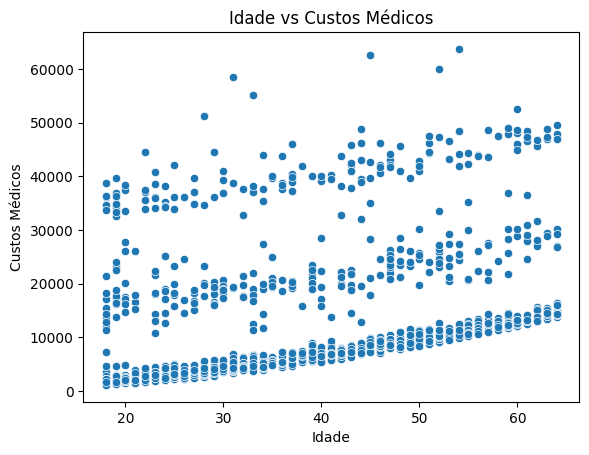

In [30]:
# Os custos médicos são influenciados pela idade?
sns.scatterplot(data=df, x='age', y='charges')
plt.title('Idade vs Custos Médicos')
plt.xlabel('Idade')
plt.ylabel('Custos Médicos')
plt.show()

### Há correlação entre IMC e Custos?

* H0: Não há correlação linear entre imc e os custos.
* H1: Há correlação linear entre imc e os custos.

In [31]:
# Correlação de Pearson
r_imc, p_value_imc = pearsonr(df['bmi'], df['charges'])
print(f'Correlação de Pearson: {r_imc:.4}, p_valor: {p_value_imc:.4}')

Correlação de Pearson: 0.1983, p_valor: 2.459e-13


Correlação positiva fraca e altamente significativa. Conforme o IMC aumenta, os custos tendem a aumentar.

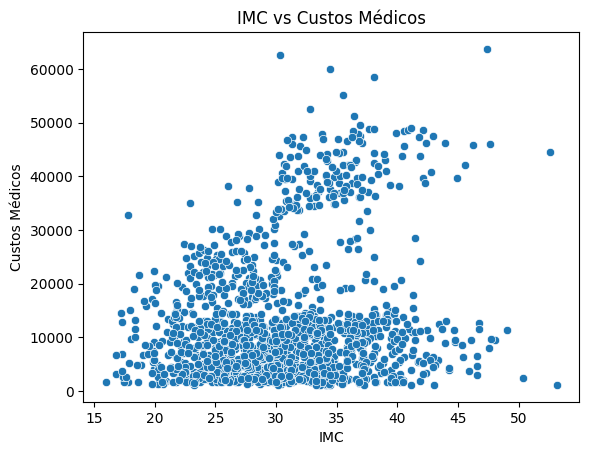

In [32]:
# Qual o impacto do IMC nos custos médicos?
sns.scatterplot(data=df, x='bmi', y='charges')
plt.title('IMC vs Custos Médicos')
plt.xlabel('IMC')
plt.ylabel('Custos Médicos')
plt.show()

### Matriz de Correlação

In [33]:
# Transformando as variáveis
df = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)    

# Visualizando o dataframe codificado
df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


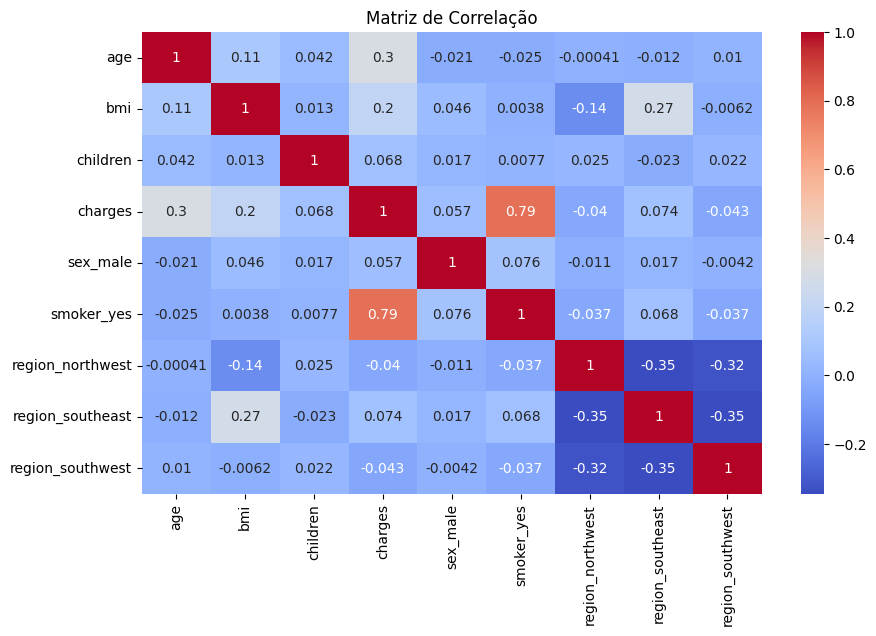

In [34]:
# Correlação entre as variáveis numéricas
plt.figure(figsize=(10,6))  
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de Correlação')
plt.show()

In [35]:
# Separando features e target
X = df.drop('charges', axis=1)
y = df['charges']

**Transformando a variável Target em log**

Ao analisar os dados, verificamos que a variável target `charges` possui assimetria alta, para melhorar os resultados dos nossos modelos, iremos utilizar o log na nossa variável target. 


In [36]:
y_log = np.log(y)

In [37]:
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42) 
print(f'Tamanho do conjunto de treino: {X_train.shape[0]}')
print(f'Tamanho do conjunto de teste: {X_test.shape[0]}')

Tamanho do conjunto de treino: 1070
Tamanho do conjunto de teste: 268


## Padronizando e normalizando os dados

In [38]:
# Inicializando a padronização
scaler = StandardScaler() # Para as features

# Colunas numéricas que precisam de padronização
colunas_num = ['age', 'bmi', 'children'] 
scaler.fit(X_train[colunas_num])

# Padronizando as FEATURES (X)
X_train_scaled = scaler.transform(X_train[colunas_num])
X_test_scaled = scaler.transform(X_test[colunas_num])

# Modelos

## Usando o Modelo de Regressão Linear

In [39]:
model = LinearRegression()
model.fit(X_train, y_train_log)

# Fazendo previsões
y_pred_log = model.predict(X_test)
y_pred_normal = np.exp(y_pred_log)

# Reversão do y_test
y_test_normal = np.exp(y_test_log)

# Avaliando o modelo
mae = mean_absolute_error(y_test_normal, y_pred_normal)
mse = mean_squared_error(y_test_normal, y_pred_normal)
r2 = r2_score(y_test_normal, y_pred_normal)

print('MAE:', mae)
print('MSE:', mse)
print('R2:', r2)

MAE: 3888.770780515872
MSE: 61079027.74116521
R2: 0.6065730962548848


## Usando o Modelo de Árvore de Decisão

In [40]:
model_dt = DecisionTreeRegressor(random_state=42)
model_dt.fit(X_train, y_train_log)

# Fazendo previsões
y_pred_dt_log = model_dt.predict(X_test)
y_pred_dt_normal = np.exp(y_pred_dt_log)


# Avaliando o modelo de árvore de decisão
mae_dt = mean_absolute_error(y_test_normal, y_pred_dt_normal)
mse_dt = mean_squared_error(y_test_normal, y_pred_dt_normal)  
r2_dt = r2_score(y_test_normal, y_pred_dt_normal)

print('MAE:', mae_dt)
print('MSE:', mse_dt)
print('R2:', r2_dt)

MAE: 2604.1581999216414
MSE: 33752258.99869101
R2: 0.7825923685535587


## Usando o Random Forest

In [41]:
model_rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
model_rf.fit(X_train, y_train_log)

# Fazendo previsões
y_pred_rf_log = model_rf.predict(X_test)
y_pred_rf_normal = np.exp(y_pred_rf_log)

# Avaliando o modelo Random Forest
mae_rf = mean_absolute_error(y_test_normal, y_pred_rf_normal)
mse_rf = mean_squared_error(y_test_normal, y_pred_rf_normal)
r2_rf = r2_score(y_test_normal, y_pred_rf_normal)

print('MAE:', mae_rf)
print('MSE:', mse_rf)
print('R2:', r2_rf)


MAE: 2075.4757612183566
MSE: 18973968.11597555
R2: 0.8777834257732343


# Tabela de Comparação entre os modelos

In [42]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'MAE': [mae, mae_dt, mae_rf],
    'MSE': [mse, mse_dt, mse_rf],
    'R^2': [r2, r2_dt, r2_rf]
})

results

,Model,MAE,MSE,R^2
0,Linear Regression,3888.770781,6.107903e+07,0.606573
1,Decision Tree,2604.158200,3.375226e+07,0.782592
2,Random Forest,2075.475761,1.897397e+07,0.877783


---

Desafio do Módulo de Machine Learning com Python - Fase 2. Pós Tech em Data Analytics (FIAP)